In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings


warnings.filterwarnings('ignore')




In [2]:
# # about data 
# his research employed a binary variable, default payment (Yes = 1, No = 0), as the response variable. This study reviewed the literature and used the following 23 variables as explanatory variables:
# X1: Amount of the given credit (NT dollar): it includes both the individual consumer credit and his/her family (supplementary) credit.
# X2: Gender (1 = male; 2 = female).
# X3: Education (1 = graduate school; 2 = university; 3 = high school; 4 = others).
# X4: Marital status (1 = married; 2 = single; 3 = others).
# X5: Age (year).
# X6 - X11: History of past payment. We tracked the past monthly payment records (from April to September, 2005) as follows: X6 = the repayment status in September, 2005; X7 = the repayment status in August, 2005; . . .;X11 = the repayment status in April, 2005. The measurement scale for the repayment status is: -1 = pay duly; 1 = payment delay for one month; 2 = payment delay for two months; . . .; 8 = payment delay for eight months; 9 = payment delay for nine months and above.
# X12-X17: Amount of bill statement (NT dollar). X12 = amount of bill statement in September, 2005; X13 = amount of bill statement in August, 2005; . . .; X17 = amount of bill statement in April, 2005. 
# X18-X23: Amount of previous payment (NT dollar). X18 = amount paid in September, 2005; X19 = amount paid in August, 2005; . . .;X23 = amount paid in April, 2005.

In [3]:
credit = pd.read_excel(
    'D:/Users/Admin/CODE FILES/AI-ML CODE/ML CODE/Credit_Card_default_DT-p7/Credit_card_data/default of credit card clients.xls',
   header = 1
)

credit



,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,29996,220000,1,3,1,39,0,0,0,0,...,88004,31237,15980,8500,20000,5003,3047,5000,1000,0
29996,29997,150000,1,3,2,43,-1,-1,-1,-1,...,8979,5190,0,1837,3526,8998,129,0,0,0
29997,29998,30000,1,2,2,37,4,3,2,-1,...,20878,20582,19357,0,0,22000,4200,2000,3100,1
29998,29999,80000,1,3,1,41,1,-1,0,0,...,52774,11855,48944,85900,3409,1178,1926,52964,1804,1


In [4]:
# bismillah

credit.shape

# 31k row and 25 feature 

(30000, 25)

In [5]:
credit.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null  int64
 14  BILL_AMT3        

In [6]:
credit.head(20)

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0
5,6,50000,1,1,2,37,0,0,0,0,...,19394,19619,20024,2500,1815,657,1000,1000,800,0
6,7,500000,1,1,2,29,0,0,0,0,...,542653,483003,473944,55000,40000,38000,20239,13750,13770,0
7,8,100000,2,2,2,23,0,-1,-1,0,...,221,-159,567,380,601,0,581,1687,1542,0
8,9,140000,2,3,1,28,0,0,2,0,...,12211,11793,3719,3329,0,432,1000,1000,1000,0
9,10,20000,1,3,2,35,-2,-2,-2,-2,...,0,13007,13912,0,0,0,13007,1122,0,0


In [7]:
credit.describe()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


In [8]:
credit.duplicated().sum()

np.int64(0)

In [9]:
# so basic is over this data is not at all messy and do t have any missing ot null  values so we are moving forward with the EDA

In [10]:
# EDA

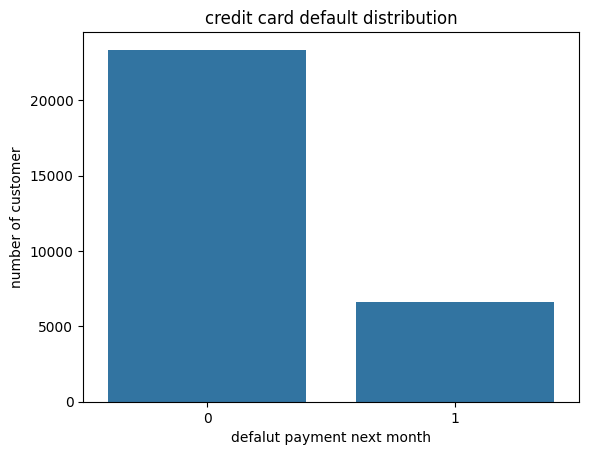

In [11]:
sns.countplot(data=credit, x='default payment next month' )

plt.title('credit card default distribution')
plt.xlabel('defalut payment next month')
plt.ylabel('number of customer')
plt.show()

In [12]:
credit['default payment next month'].value_counts()

default payment next month
0    23364
1     6636
Name: count, dtype: int64

In [13]:
credit['default payment next month'].value_counts(normalize=True) * 100

# 

default payment next month
0    77.88
1    22.12
Name: proportion, dtype: float64

In [14]:
# 77% is default to not and 22% is default  
# the target if defineitly imbalanced as we can see the diffrence is 77 22 
# i genuinly dont know at this point that is this going to make or create problem for out decision tree i think its too early to judge
# if a model predicts 100% no default but acctual is 77 so i this accuracy well get is around 80 


In [15]:
# now we are starting to investigate the remaining features -->
# 1. sex

In [16]:
credit['SEX'].value_counts()

SEX
2    18112
1    11888
Name: count, dtype: int64

In [17]:
pd.crosstab(
    credit['SEX'],
    credit['default payment next month'],
    normalize='index'

) * 100

default payment next month,0,1
SEX,,
1,75.832773,24.167227
2,79.223719,20.776281


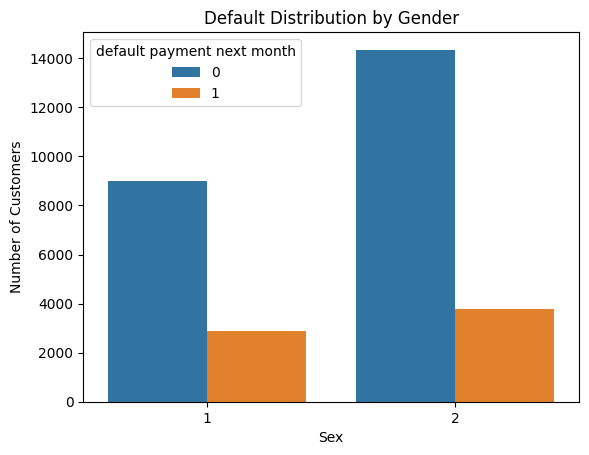

In [18]:
sns.countplot(
    data=credit,
    x='SEX',
    hue='default payment next month',
    
)

plt.title('Default Distribution by Gender')
plt.xlabel('Sex')
plt.ylabel('Number of Customers')
plt.show()

In [19]:
# what my observation here is that there are more womens in this then males and if look from that prespective then there is a clear diffrence in the one default and no default in here wommen men are more like to pay then women 

In [20]:
# EDUCATION

# so my understanding and chronology for the education is that the more educated the better job they have and better chances to pay the default

In [21]:
credit['EDUCATION']

0        2
1        2
2        2
3        2
4        2
        ..
29995    3
29996    3
29997    2
29998    3
29999    2
Name: EDUCATION, Length: 30000, dtype: int64

In [22]:
pd.crosstab(
    credit['EDUCATION'],
    credit['default payment next month'],
    normalize='index'
) * 100

default payment next month,0,1
EDUCATION,,
0,100.000000,0.000000
1,80.765234,19.234766
2,76.265146,23.734854
3,74.842384,25.157616
4,94.308943,5.691057
5,93.571429,6.428571
6,84.313725,15.686275


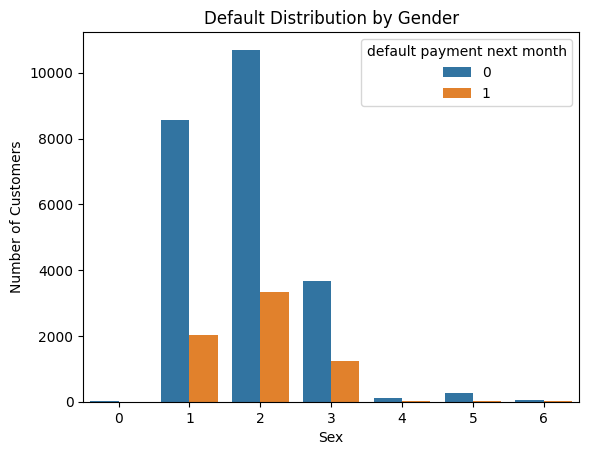

In [23]:
sns.countplot(
    data=credit,
    x='EDUCATION',
    hue='default payment next month',
    
)

plt.title('Default Distribution by Gender')
plt.xlabel('Sex')
plt.ylabel('Number of Customers')
plt.show()

In [24]:
credit['EDUCATION'].value_counts().sort_index()

EDUCATION
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64

In [25]:
# PAY --> now we move towards the clustered feature and what i mean by that , there are cluster ofn feature containing the same information, now lets see how to deal with them 

# sept to march

# The measurement scale for the repayment status is: -1 = pay duly; 1 = payment delay for one month; 2 = payment delay for two months; . . .; 8 = payment delay for eight months; 9 = payment delay for nine months and above.

credit

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,29996,220000,1,3,1,39,0,0,0,0,...,88004,31237,15980,8500,20000,5003,3047,5000,1000,0
29996,29997,150000,1,3,2,43,-1,-1,-1,-1,...,8979,5190,0,1837,3526,8998,129,0,0,0
29997,29998,30000,1,2,2,37,4,3,2,-1,...,20878,20582,19357,0,0,22000,4200,2000,3100,1
29998,29999,80000,1,3,1,41,1,-1,0,0,...,52774,11855,48944,85900,3409,1178,1926,52964,1804,1


In [26]:
credit['PAY_0'].value_counts().sort_index()


# The measurement scale for the repayment status is: -1 = pay duly; 1 = payment delay for one month; 2 = payment delay for two months; . . .; 8 = payment delay for eight months; 9 = payment delay for nine months and above.


PAY_0
-2     2759
-1     5686
 0    14737
 1     3688
 2     2667
 3      322
 4       76
 5       26
 6       11
 7        9
 8       19
Name: count, dtype: int64

In [27]:
pd.crosstab(
    credit['PAY_0'],
    credit['default payment next month'],
    normalize='index'
) * 100

default payment next month,0,1
PAY_0,,
-2,86.770569,13.229431
-1,83.221949,16.778051
0,87.188709,12.811291
1,66.052061,33.947939
2,30.858643,69.141357
3,24.223602,75.776398
4,31.578947,68.421053
5,50.000000,50.000000
6,45.454545,54.545455


In [28]:
pay_cols = ['PAY_6', 'PAY_5', 'PAY_4', 'PAY_3', 'PAY_2', 'PAY_0']

for col in pay_cols:
    print(f"\n===== {col} =====")
    print(
        pd.crosstab(
            credit[col],
            credit['default payment next month'],
            normalize='index'
        ) * 100
    )


===== PAY_6 =====
default payment next month          0           1
PAY_6                                            
-2                          79.959142   20.040858
-1                          83.013937   16.986063
 0                          81.155594   18.844406
 2                          49.349241   50.650759
 3                          35.869565   64.130435
 4                          36.734694   63.265306
 5                          46.153846   53.846154
 6                          26.315789   73.684211
 7                          17.391304   82.608696
 8                           0.000000  100.000000

===== PAY_5 =====
default payment next month          0           1
PAY_5                                            
-2                          80.312363   19.687637
-1                          83.805741   16.194259
 0                          81.147106   18.852894
 2                          45.811120   54.188880
 3                          36.516854   63.483146
 4          

In [29]:
credit

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,29996,220000,1,3,1,39,0,0,0,0,...,88004,31237,15980,8500,20000,5003,3047,5000,1000,0
29996,29997,150000,1,3,2,43,-1,-1,-1,-1,...,8979,5190,0,1837,3526,8998,129,0,0,0
29997,29998,30000,1,2,2,37,4,3,2,-1,...,20878,20582,19357,0,0,22000,4200,2000,3100,1
29998,29999,80000,1,3,1,41,1,-1,0,0,...,52774,11855,48944,85900,3409,1178,1926,52964,1804,1


In [30]:
# note : okay so according to the ai we have wasted our time on find and understanding the data and under standing the busines
# where there was no need for it. we need to follow this rule from now on when ever we sit and do eda 

# Level 1 — What does the column mean?

# For example:

# PAY_0 = repayment status for September.

# Good.

# Level 2 — What do the values mean?

# For example:

# 2 = payment delay of 2 months.

# Good.

# Level 3 — Can I explain every individual row perfectly?

# Not necessarily.

# You don't need to be able to explain:

# "Why exactly did Customer #1 have this particular combination of numbers?"

# unless there's a specific data-quality investigation.

# Your job is to understand enough to use the feature correctly and identify suspicious patterns.


# Your EDA should answer:

# "What kind of customers are in this dataset, what does their financial behavior look like, and what patterns are associated with default?"

# That's your actual goal.

In [31]:
# NEED TO ASK SOME QUESTION WHILE SOLVING THE EDA!!!

# Question 1 — Is the dataset healthy?

# Before asking anything about customers, check the dataset itself.

# You want to know:

# How many rows?
# How many columns?
# Are there duplicates?
# Are there missing values?
# Are there impossible values?
# Are there weird categories?
# Are numeric columns actually numeric?
# Are there suspicious outliers?


# Question 2 — Understand each feature

# Don't look at all 24 columns as one giant mess.

# Divide them into groups.



# Question 3 — Is the target balanced?

# This is very important.

# Suppose you have:

# 90,000 customers
# 89,000 → no default
# 1,000 → default

# A stupid model could say:

# "Nobody defaults."
# And it would still get:

# 98.9% accuracy

# That sounds amazing.

# But the model would be useless.

# You want to understand:

# How common is default?

# This will later affect how we evaluate the model.


# Question 4 — Which features appear related to default?

# THIS is the heart of your EDA.

# Now we start asking:

# "What looks different between people who defaulted and people who didn't?"

# Maybe you'll discover:

# Defaulting customers tend to be younger.

# Maybe not.

# We don't assume. We investigate.

In [32]:
pay_cols = ['PAY_6','PAY_5', 'PAY_4', 'PAY_3', 'PAY_2', 'PAY_0']

for col in pay_cols:
    print(f"\n===== {col} =====")
    print(credit[col].value_counts().sort_index())


===== PAY_6 =====
PAY_6
-2     4895
-1     5740
 0    16286
 2     2766
 3      184
 4       49
 5       13
 6       19
 7       46
 8        2
Name: count, dtype: int64

===== PAY_5 =====
PAY_5
-2     4546
-1     5539
 0    16947
 2     2626
 3      178
 4       84
 5       17
 6        4
 7       58
 8        1
Name: count, dtype: int64

===== PAY_4 =====
PAY_4
-2     4348
-1     5687
 0    16455
 1        2
 2     3159
 3      180
 4       69
 5       35
 6        5
 7       58
 8        2
Name: count, dtype: int64

===== PAY_3 =====
PAY_3
-2     4085
-1     5938
 0    15764
 1        4
 2     3819
 3      240
 4       76
 5       21
 6       23
 7       27
 8        3
Name: count, dtype: int64

===== PAY_2 =====
PAY_2
-2     3782
-1     6050
 0    15730
 1       28
 2     3927
 3      326
 4       99
 5       25
 6       12
 7       20
 8        1
Name: count, dtype: int64

===== PAY_0 =====
PAY_0
-2     2759
-1     5686
 0    14737
 1     3688
 2     2667
 3      322
 4       76


In [33]:
# my observation which ill keep in brief , in here the first of all we dont have any discription for the -2  and 0 what this singnify are  assuminf those are the one which data we dont hav e from the bank 

# the thingg is that the number nor small 
# so there are no such or rate thing and we didnt fnd any outliers hwrere till now

In [34]:
print(credit.columns.tolist())

['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default payment next month']


In [35]:
for col in pay_cols:
    print(f"\n===== {col} =====")
    
    result = pd.crosstab(
        credit[col],
        credit['default payment next month'],
        normalize='index'
    ) * 100
    
    print(result)


===== PAY_6 =====
default payment next month          0           1
PAY_6                                            
-2                          79.959142   20.040858
-1                          83.013937   16.986063
 0                          81.155594   18.844406
 2                          49.349241   50.650759
 3                          35.869565   64.130435
 4                          36.734694   63.265306
 5                          46.153846   53.846154
 6                          26.315789   73.684211
 7                          17.391304   82.608696
 8                           0.000000  100.000000

===== PAY_5 =====
default payment next month          0           1
PAY_5                                            
-2                          80.312363   19.687637
-1                          83.805741   16.194259
 0                          81.147106   18.852894
 2                          45.811120   54.188880
 3                          36.516854   63.483146
 4          

In [36]:
# the cross tab is quite common here and normal , ppl who are paying and have less late month or dure monts are more tend to be in the non default

In [37]:
# bill feature 


bill_cols = [
    'BILL_AMT1',
    'BILL_AMT2',
    'BILL_AMT3',
    'BILL_AMT4',
    'BILL_AMT5',
    'BILL_AMT6'
]

credit[bill_cols].describe()

,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6
count,30000.000000,30000.000000,3.000000e+04,30000.000000,30000.000000,30000.000000
mean,51223.330900,49179.075167,4.701315e+04,43262.948967,40311.400967,38871.760400
std,73635.860576,71173.768783,6.934939e+04,64332.856134,60797.155770,59554.107537
min,-165580.000000,-69777.000000,-1.572640e+05,-170000.000000,-81334.000000,-339603.000000
25%,3558.750000,2984.750000,2.666250e+03,2326.750000,1763.000000,1256.000000
50%,22381.500000,21200.000000,2.008850e+04,19052.000000,18104.500000,17071.000000
75%,67091.000000,64006.250000,6.016475e+04,54506.000000,50190.500000,49198.250000
max,964511.000000,983931.000000,1.664089e+06,891586.000000,927171.000000,961664.000000


In [38]:
credit.groupby('default payment next month')[bill_cols].mean()

# there is no as such differences in the bills of the defaulter and non defaulters 


,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6
default payment next month,,,,,,
0,51994.227273,49717.435670,47533.365605,43611.165254,40530.445343,39042.268704
1,48509.162297,47283.617842,45181.598855,42036.950573,39540.190476,38271.435503


In [39]:
negative_bill = credit[credit['BILL_AMT1'] < 0]

negative_bill[['BILL_AMT1', 'PAY_AMT1', 'default payment next month']].describe()

,BILL_AMT1,PAY_AMT1,default payment next month
count,590.000000,590.000000,590.000000
mean,-1154.796610,8765.271186,0.184746
std,9426.165151,31975.595914,0.388420
min,-165580.000000,0.000000,0.000000
25%,-430.750000,0.000000,0.000000
50%,-90.500000,157.000000,0.000000
75%,-11.000000,3434.750000,0.000000
max,-1.000000,505000.000000,1.000000


In [40]:
negative_bill.head(20)

# even if there bill is in negative still they are mannaging to pay the ammount , either i can be ann error which needs to be fixed or might be something else we need to find out 

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
26,27,60000,1,1,2,27,1,-2,-1,-1,...,-57,127,-189,0,1000,0,500,0,1000,1
68,69,130000,2,3,2,29,1,-2,-2,-1,...,10311,10161,7319,0,0,20161,0,7319,13899,0
92,93,100000,2,1,2,27,-2,-2,-2,-2,...,0,0,0,7555,0,0,0,0,0,0
101,102,380000,2,1,2,30,-2,-2,-1,0,...,32891,33564,34056,223,33178,1171,1197,1250,5000,0
109,110,360000,1,2,1,35,1,-2,-2,-2,...,-103,-103,-103,0,0,0,0,0,0,0
149,150,260000,2,1,1,60,1,-2,-1,-1,...,0,969,869,0,22500,0,969,1000,0,0
173,174,50000,2,1,2,24,1,-2,-2,-2,...,-2898,-3272,-3272,0,0,0,0,0,0,1
216,217,240000,2,2,1,36,1,-2,-2,-2,...,-946,-946,-946,0,0,0,0,0,0,1
319,320,180000,1,2,2,29,1,-2,-2,-2,...,-2,-2,-2,0,0,0,0,0,0,0
330,331,200000,2,2,1,37,1,-1,2,-1,...,6773,23209,16893,1000,0,6900,24000,17000,2500,1


In [41]:
credit[credit['BILL_AMT1'] < 0]['default payment next month'].value_counts(normalize=True) * 100
# credit[credit['BILL_AMT1'] < 0]['default payment next month'].value_counts()

default payment next month
0    81.525424
1    18.474576
Name: proportion, dtype: float64

In [42]:
for col in bill_cols:
    print(col, (credit[col] < 0).sum())

BILL_AMT1 590
BILL_AMT2 669
BILL_AMT3 655
BILL_AMT4 675
BILL_AMT5 655
BILL_AMT6 688


In [43]:
# # How to build the intution for writing the code to investigate 

# here is the simple mental frame work  for it 

# 1. What values does it contain?

# "What is actually inside this column?"

# Use:

# value_counts()
# unique()
# describe()


# 2. Is anything weird?

# Ask:

# "Are there missing, impossible, negative, enormous, or suspicious values?"

# Examples:

# isna().sum()
# (value < 0).sum()
# value_counts()
# describe()


# 3. How does it relate to my target?

# This is the big one.

# Ask:

# "Do people in different target groups behave differently?"

# For numerical variables:

# credit.groupby('target')['feature'].mean()

# or:

# credit.groupby('target')['feature'].median()

# For categorical variables:

# pd.crosstab(
#     credit['feature'],
#     credit['target'],
#     normalize='index'
# ) * 100


# 4. Is there a pattern across time?

# This is particularly important for our dataset because we have six months.

# Ask:

# "Is this feature changing from month to month?"

# For example:

# credit[bill_cols].mean()

# or:

# credit[pay_cols].mean()


# 5. Is the pattern actually important?

# This is where you stop yourself from overdoing EDA.

# Ask:

# "Is this worth investigating further?"

# For example:

# Negative BILL_AMT

# ~600 out of 30,000.

# That's roughly 2%.

# Interesting → flag it.

# But:

# "Let's investigate every one of those 600 customers."

# ❌ No.

# We don't have evidence that it's important to our ML problem.

In [44]:
# Bill amounts contain some negative and extreme values, but they represent only a small portion of the dataset. We don't currently have evidence that they are erroneous, so we won't modify them. The average bill amount also decreases across the six months, but we won't invent a reason for that trend.

In [45]:
# PAYMENT AMOUT FEATURE 

In [46]:

payment_cols = [
    'PAY_AMT1',
    'PAY_AMT2',
    'PAY_AMT3',
    'PAY_AMT4',
    'PAY_AMT5',
    'PAY_AMT6'
]

credit[payment_cols].describe()

# so yeah i coudlnt find any negative values in it . nor any abnormality

,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
count,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000
mean,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567
std,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775
min,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000
25%,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000
50%,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000
75%,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000
max,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000


In [47]:
credit.groupby('default payment next month')[payment_cols].mean()
credit.groupby('default payment next month')[payment_cols].describe().T

# so in this one trend is pretty clear that the ppl who are paying consistently safe and the one who is not consistent are getting 

default payment next month             0              1
PAY_AMT1 count              2.336400e+04    6636.000000
         mean               6.307337e+03    3397.044153
         std                1.801451e+04    9544.252427
         min                0.000000e+00       0.000000
         25%                1.163750e+03       0.000000
         50%                2.459500e+03    1636.000000
         75%                5.606250e+03    3478.250000
         max                8.735520e+05  300000.000000
PAY_AMT2 count              2.336400e+04    6636.000000
         mean               6.640465e+03    3388.649638
         std                2.530226e+04   11737.986064
         min                0.000000e+00       0.000000
         25%                1.005000e+03       0.000000
         50%                2.247500e+03    1533.500000
         75%                5.311250e+03    3309.750000
         max                1.684259e+06  358689.000000
PAY_AMT3 count              2.336400e+04    6636.000000
         mean               5.753497e+03    3367.351567
         std                1.868426e+04   12959.624486
         min                0.000000e+00       0.000000
         25%                6.000000e+02       0.000000
         50%                2.000000e+03    1222.000000
         75%                5.000000e+03    3000.000000
         max                8.960400e+05  508229.000000
PAY_AMT4 count              2.336400e+04    6636.000000
         mean               5.300529e+03    3155.626733
         std                1.668978e+04   11191.973162
         min                0.000000e+00       0.000000
         25%                3.900000e+02       0.000000
         50%                1.734000e+03    1000.000000
         75%                4.602000e+03    2939.250000
         max                6.210000e+05  432130.000000
PAY_AMT5 count              2.336400e+04    6636.000000
         mean               5.248220e+03    3219.139542
         std                1.607167e+04   11944.731175
         min                0.000000e+00       0.000000
         25%                3.690000e+02       0.000000
         50%                1.765000e+03    1000.000000
         75%                4.600000e+03    3000.000000
         max                4.265290e+05  332000.000000
PAY_AMT6 count              2.336400e+04    6636.000000
         mean               5.719372e+03    3441.482068
         std                1.879295e+04   13464.005894
         min                0.000000e+00       0.000000
         25%                3.000000e+02       0.000000
         50%                1.706000e+03    1000.000000
         75%                4.545000e+03    2974.500000
         max                5.286660e+05  345293.000000

In [48]:


# Payment amounts contain no negative values. Zero payments exist. The distribution is highly right-skewed, with most customers making relatively small payments and a small number making extremely large payments. Payment amounts also appear to differ between customers who do and don't default, but exact payment ranges need to be handled carefully because of the skew.

In [49]:
# so now we are working on the corelation btw the feture and target . lets goo


# Correlation mainly measures linear relationships. A Decision Tree can find nonlinear relationships that correlation doesn't capture.  

In [50]:
# trying to find the correlation matrix.

correlation = credit.corr(numeric_only=True)

correlation

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
ID,1.000000,0.026179,0.018497,0.039177,-0.029079,0.018678,-0.030575,-0.011215,-0.018494,-0.002735,...,0.040351,0.016705,0.016730,0.009742,0.008406,0.039151,0.007793,0.000652,0.003000,-0.013952
LIMIT_BAL,0.026179,1.000000,0.024755,-0.219161,-0.108139,0.144713,-0.271214,-0.296382,-0.286123,-0.267460,...,0.293988,0.295562,0.290389,0.195236,0.178408,0.210167,0.203242,0.217202,0.219595,-0.153520
SEX,0.018497,0.024755,1.000000,0.014232,-0.031389,-0.090874,-0.057643,-0.070771,-0.066096,-0.060173,...,-0.021880,-0.017005,-0.016733,-0.000242,-0.001391,-0.008597,-0.002229,-0.001667,-0.002766,-0.039961
EDUCATION,0.039177,-0.219161,0.014232,1.000000,-0.143464,0.175061,0.105364,0.121566,0.114025,0.108793,...,-0.000451,-0.007567,-0.009099,-0.037456,-0.030038,-0.039943,-0.038218,-0.040358,-0.037200,0.028006
MARRIAGE,-0.029079,-0.108139,-0.031389,-0.143464,1.000000,-0.414170,0.019917,0.024199,0.032688,0.033122,...,-0.023344,-0.025393,-0.021207,-0.005979,-0.008093,-0.003541,-0.012659,-0.001205,-0.006641,-0.024339
AGE,0.018678,0.144713,-0.090874,0.175061,-0.414170,1.000000,-0.039447,-0.050148,-0.053048,-0.049722,...,0.051353,0.049345,0.047613,0.026147,0.021785,0.029247,0.021379,0.022850,0.019478,0.013890
PAY_0,-0.030575,-0.271214,-0.057643,0.105364,0.019917,-0.039447,1.000000,0.672164,0.574245,0.538841,...,0.179125,0.180635,0.176980,-0.079269,-0.070101,-0.070561,-0.064005,-0.058190,-0.058673,0.324794
PAY_2,-0.011215,-0.296382,-0.070771,0.121566,0.024199,-0.050148,0.672164,1.000000,0.766552,0.662067,...,0.222237,0.221348,0.219403,-0.080701,-0.058990,-0.055901,-0.046858,-0.037093,-0.036500,0.263551
PAY_3,-0.018494,-0.286123,-0.066096,0.114025,0.032688,-0.053048,0.574245,0.766552,1.000000,0.777359,...,0.227202,0.225145,0.222327,0.001295,-0.066793,-0.053311,-0.046067,-0.035863,-0.035861,0.235253
PAY_4,-0.002735,-0.267460,-0.060173,0.108793,0.033122,-0.049722,0.538841,0.662067,0.777359,1.000000,...,0.245917,0.242902,0.239154,-0.009362,-0.001944,-0.069235,-0.043461,-0.033590,-0.026565,0.216614


In [51]:
# Target is imbalanced.
# Payment-delay behavior has a noticeable relationship with the target.
# Recent payment status appears more strongly associated with the target than older status.
# PAY columns are strongly related to one another.
# Bill columns are extremely related to one another.
# Bill amount has almost no linear correlation with the target.
# Payment amount has a weak negative linear correlation with the target.
# Correlation alone cannot determine what the Decision Tree will ultimately find useful.

In [52]:
credit['PAY_MAX'] = credit[pay_cols].max(axis=1)
credit['PAY_AVG'] = credit[pay_cols].mean(axis=1)
credit['PAY_TREND'] = credit['PAY_0'] - credit['PAY_6']
credit[['PAY_0','PAY_6','PAY_TREND']]

# we can create all this feature to make or 

,PAY_0,PAY_6,PAY_TREND
0,2,-2,4
1,-1,2,-3
2,0,0,0
3,0,0,0
4,-1,0,-1
...,...,...,...
29995,0,0,0
29996,-1,0,-1
29997,4,0,4
29998,1,-1,2


In [53]:
correlation = credit.corr(numeric_only=True)

correlation

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month,PAY_MAX,PAY_AVG,PAY_TREND
ID,1.000000,0.026179,0.018497,0.039177,-0.029079,0.018678,-0.030575,-0.011215,-0.018494,-0.002735,...,0.009742,0.008406,0.039151,0.007793,0.000652,0.003000,-0.013952,-0.035273,-0.020632,-0.009479
LIMIT_BAL,0.026179,1.000000,0.024755,-0.219161,-0.108139,0.144713,-0.271214,-0.296382,-0.286123,-0.267460,...,0.195236,0.178408,0.210167,0.203242,0.217202,0.219595,-0.153520,-0.294486,-0.316961,-0.029441
SEX,0.018497,0.024755,1.000000,0.014232,-0.031389,-0.090874,-0.057643,-0.070771,-0.066096,-0.060173,...,-0.000242,-0.001391,-0.008597,-0.002229,-0.001667,-0.002766,-0.039961,-0.058128,-0.069908,-0.012157
EDUCATION,0.039177,-0.219161,0.014232,1.000000,-0.143464,0.175061,0.105364,0.121566,0.114025,0.108793,...,-0.037456,-0.030038,-0.039943,-0.038218,-0.040358,-0.037200,0.028006,0.085161,0.124347,0.020371
MARRIAGE,-0.029079,-0.108139,-0.031389,-0.143464,1.000000,-0.414170,0.019917,0.024199,0.032688,0.033122,...,-0.005979,-0.008093,-0.003541,-0.012659,-0.001205,-0.006641,-0.024339,0.027932,0.035477,-0.014681
AGE,0.018678,0.144713,-0.090874,0.175061,-0.414170,1.000000,-0.039447,-0.050148,-0.053048,-0.049722,...,0.026147,0.021785,0.029247,0.021379,0.022850,0.019478,0.013890,-0.049913,-0.058217,0.010087
PAY_0,-0.030575,-0.271214,-0.057643,0.105364,0.019917,-0.039447,1.000000,0.672164,0.574245,0.538841,...,-0.079269,-0.070101,-0.070561,-0.064005,-0.058190,-0.058673,0.324794,0.765436,0.741345,0.495908
PAY_2,-0.011215,-0.296382,-0.070771,0.121566,0.024199,-0.050148,0.672164,1.000000,0.766552,0.662067,...,-0.080701,-0.058990,-0.055901,-0.046858,-0.037093,-0.036500,0.263551,0.692618,0.850428,0.080262
PAY_3,-0.018494,-0.286123,-0.066096,0.114025,0.032688,-0.053048,0.574245,0.766552,1.000000,0.777359,...,0.001295,-0.066793,-0.053311,-0.046067,-0.035863,-0.035861,0.235253,0.703297,0.878080,-0.070552
PAY_4,-0.002735,-0.267460,-0.060173,0.108793,0.033122,-0.049722,0.538841,0.662067,0.777359,1.000000,...,-0.009362,-0.001944,-0.069235,-0.043461,-0.033590,-0.026565,0.216614,0.674361,0.890987,-0.187322


In [54]:
X = credit.drop('default payment next month', axis=1)
y = credit['default payment next month']

X = X.drop('ID', axis=1)
y

0        1
1        1
2        0
3        0
4        0
        ..
29995    0
29996    0
29997    1
29998    1
29999    1
Name: default payment next month, Length: 30000, dtype: int64

In [55]:
print(X.shape)
print(y.shape)

(30000, 26)
(30000,)


In [56]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [57]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(24000, 26)
(24000,)
(6000, 26)
(6000,)


In [58]:
print(X.shape)
print(X.columns)
print(X.isnull().sum().sum())

(30000, 26)
Index(['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2',
       'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'PAY_MAX',
       'PAY_AVG', 'PAY_TREND'],
      dtype='str')
0


In [59]:
from sklearn.tree import DecisionTreeClassifier

DT_model = DecisionTreeClassifier(
    random_state=42
)

DT_model.fit(X_train,y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [60]:
y_pred = DT_model.predict(X_test)

In [61]:
from sklearn.metrics import accuracy_score

train_pred = DT_model.predict(X_train)
test_pred = DT_model.predict(X_test)

print("Training Accuracy:", accuracy_score(y_train, train_pred))
print("Testing Accuracy:", accuracy_score(y_test, test_pred))

Training Accuracy: 0.9994583333333333
Testing Accuracy: 0.7216666666666667


In [62]:
# The tree has become too good at remembering the training customers instead of learning patterns that generalize to new customers.

In [63]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

# tn - 3800  fp - 873 = 4673 <= neg
# fn - 797   tp - 530 = 1327 <= pos
                      # 6000

[[3800  873]
 [ 797  530]]


Accuracy=
6000/
3800+530
	​

=72.17%

In [64]:
sorted(y_test.unique())

[np.int64(0), np.int64(1)]

In [65]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.81      0.82      4673
           1       0.38      0.40      0.39      1327

    accuracy                           0.72      6000
   macro avg       0.60      0.61      0.60      6000
weighted avg       0.73      0.72      0.72      6000



In [66]:
# the model is over fitted need to fix it , the testing accuracy is 99% and test accuracy is 72%

In [67]:
# checking how complicated our tree is 

print("tree depth:", DT_model.get_depth())
print("number of leaves:", DT_model.get_n_leaves())

tree depth: 52
number of leaves: 3764


In [68]:
# we are testing  diffrent depts for the tree 

depths = [2, 3, 5, 7, 10, 15, 20, 30, 40, 50]

# now well try ouyt every depth by training them 

for depth in depths:

    tree = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    tree.fit(X_train, y_train)

    train_pred = tree.predict(X_train)
    test_pred = tree.predict(X_test)

    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)

    print(
        f"Depth: {depth:2} | "
        f"Train: {train_acc:.4f} | "
        f"Test: {test_acc:.4f}"
    )


    # the breaking point for this decision tree is deppt 7 , with dept 7 its giving the best result

Depth:  2 | Train: 0.8200 | Test: 0.8168
Depth:  3 | Train: 0.8213 | Test: 0.8188
Depth:  5 | Train: 0.8252 | Test: 0.8188
Depth:  7 | Train: 0.8297 | Test: 0.8145
Depth: 10 | Train: 0.8448 | Test: 0.8082
Depth: 15 | Train: 0.8989 | Test: 0.7780
Depth: 20 | Train: 0.9535 | Test: 0.7440
Depth: 30 | Train: 0.9925 | Test: 0.7270
Depth: 40 | Train: 0.9983 | Test: 0.7237
Depth: 50 | Train: 0.9994 | Test: 0.7230


In [69]:
# after depth we are solely trying out the min sample split to see its raw effect on the dataset


split_values = [2, 5, 10, 20, 50, 100, 200, 500, 1000,1500,2000,30000]

for split in split_values:

    tree = DecisionTreeClassifier(
        min_samples_split=split,
        random_state=42
    )

    tree.fit(X_train, y_train)

    train_pred = tree.predict(X_train)
    test_pred = tree.predict(X_test)

    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)

    print(
        f"min_samples_split: {split:3} | "
        f"Train: {train_acc:.4f} | "
        f"Test: {test_acc:.4f}"
    )

# the best results come out when the tree is restrictive i  this case 200 sample splits have the best testing and training result

min_samples_split:   2 | Train: 0.9995 | Test: 0.7217
min_samples_split:   5 | Train: 0.9730 | Test: 0.7357
min_samples_split:  10 | Train: 0.9377 | Test: 0.7392
min_samples_split:  20 | Train: 0.9005 | Test: 0.7508
min_samples_split:  50 | Train: 0.8670 | Test: 0.7762
min_samples_split: 100 | Train: 0.8487 | Test: 0.7923
min_samples_split: 200 | Train: 0.8373 | Test: 0.8033
min_samples_split: 500 | Train: 0.8272 | Test: 0.8112
min_samples_split: 1000 | Train: 0.8239 | Test: 0.8157
min_samples_split: 1500 | Train: 0.8208 | Test: 0.8155
min_samples_split: 2000 | Train: 0.8203 | Test: 0.8162
min_samples_split: 30000 | Train: 0.7788 | Test: 0.7788


In [70]:
# now we are trying the min sample leaf

# min_samples_leaf

# asks:

# "After I split this group, how many customers must remain in EACH resulting group?"

In [71]:


leaf_values = [1, 5, 10, 20, 50, 100, 200, 500]

for leaf in leaf_values:

    tree = DecisionTreeClassifier(
        min_samples_leaf=leaf,
        random_state=42
    )

    tree.fit(X_train, y_train)

    train_pred = tree.predict(X_train)
    test_pred = tree.predict(X_test)

    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)

    print(
        f"min_samples_leaf: {leaf:3} | "
        f"Train: {train_acc:.4f} | "
        f"Test: {test_acc:.4f}"
    )

min_samples_leaf:   1 | Train: 0.9995 | Test: 0.7217
min_samples_leaf:   5 | Train: 0.9065 | Test: 0.7448
min_samples_leaf:  10 | Train: 0.8660 | Test: 0.7720
min_samples_leaf:  20 | Train: 0.8417 | Test: 0.7900
min_samples_leaf:  50 | Train: 0.8292 | Test: 0.8095
min_samples_leaf: 100 | Train: 0.8248 | Test: 0.8155
min_samples_leaf: 200 | Train: 0.8227 | Test: 0.8147
min_samples_leaf: 500 | Train: 0.8203 | Test: 0.8172


In [84]:
# now we are combining all three with cross validation.

from sklearn.model_selection import GridSearchCV

tree = DecisionTreeClassifier(
    random_state=42
)


param_grid = {
    'max_depth': [3, 5, 7, 10],
    'min_samples_split': [100, 500, 1000, 2000],
    'min_samples_leaf': [50, 100, 200, 500]
}
grid_search = GridSearchCV(
    estimator=tree,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)
print("Best parameters:")
print(grid_search.best_params_)

print("\nBest CV score:")
print(grid_search.best_score_)
# Get the best tree found by GridSearchCV
best_tree = grid_search.best_estimator_

# Make predictions on our untouched test set
y_pred_best = best_tree.predict(X_test)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, y_pred_best))
print("Precision:", precision_score(y_test, y_pred_best))
print("Recall   :", recall_score(y_test, y_pred_best))
print("F1 Score :", f1_score(y_test, y_pred_best))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_best))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best))

Best parameters:
{'max_depth': 5, 'min_samples_leaf': 50, 'min_samples_split': 100}

Best CV score:
0.8217916666666667
Accuracy : 0.819
Precision: 0.6754002911208151
Recall   : 0.3496608892238131
F1 Score : 0.46077457795431975

Confusion Matrix:
[[4450  223]
 [ 863  464]]

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.95      0.89      4673
           1       0.68      0.35      0.46      1327

    accuracy                           0.82      6000
   macro avg       0.76      0.65      0.68      6000
weighted avg       0.80      0.82      0.80      6000



In [79]:
# --------old---------

# tn - 3800  fp - 873 = 4673 <= neg
# fn - 797   tp - 530 = 1327 <= pos
                      # 6000


# --------new---------

# tn - 4450    fp - 223 = 4673 <= neg
# fn - 863     tp - 464 = 1327 <= pos
                      # 6000

In [80]:
# so our recall is still not up to the mark we need to add class weight to make balance btw the precision and recall 


In [81]:
tree = DecisionTreeClassifier(
    class_weight='balanced',
    random_state=42
)

param_grid = {
    'max_depth': [3, 5, 7, 10],
    'min_samples_split': [100, 500, 1000, 2000],
    'min_samples_leaf': [50, 100, 200, 500]
}

grid_search = GridSearchCV(
    estimator=tree,
    param_grid=param_grid,
    cv=5,
    scoring='recall',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters:")
print(grid_search.best_params_)

print("\nBest CV recall:")
print(grid_search.best_score_)

best_tree = grid_search.best_estimator_

y_pred_best = best_tree.predict(X_test)

Best parameters:
{'max_depth': 10, 'min_samples_leaf': 100, 'min_samples_split': 100}

Best CV recall:
0.6675461624342598


In [83]:
# Make predictions on our untouched test set
y_pred_best = best_tree.predict(X_test)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, y_pred_best))
print("Precision:", precision_score(y_test, y_pred_best))
print("Recall   :", recall_score(y_test, y_pred_best))
print("F1 Score :", f1_score(y_test, y_pred_best))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_best))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best))

Accuracy : 0.7086666666666667
Precision: 0.40444847934634587
Recall   : 0.6714393368500376
F1 Score : 0.5048158640226629

Confusion Matrix:
[[3361 1312]
 [ 436  891]]

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.72      0.79      4673
           1       0.40      0.67      0.50      1327

    accuracy                           0.71      6000
   macro avg       0.64      0.70      0.65      6000
weighted avg       0.78      0.71      0.73      6000



In [ ]:

# --------old---------

# tn - 4450    fp - 223 = 4673 <= neg
# fn - 863     tp - 464 = 1327 <= pos
                      # 6000

# --------new---------

# tn - 3361     fp - 1312 = 4673 <= neg
# fn - 436       tp - 891 = 1327 <= pos
                      # 6000

In [ ]:
# Ṇow we have 2 models 1 is good at finding the defaulter and other non defaulters 
# so now well work tunning threshold 

In [85]:
# Probability that each customer will default
y_prob = best_tree.predict_proba(X_test)[:, 1]


from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

thresholds = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]

for threshold in thresholds:

    y_pred_threshold = (y_prob >= threshold).astype(int)

    accuracy = accuracy_score(y_test, y_pred_threshold)
    precision = precision_score(y_test, y_pred_threshold)
    recall = recall_score(y_test, y_pred_threshold)
    f1 = f1_score(y_test, y_pred_threshold)

    print(
        f"Threshold: {threshold:.2f} | "
        f"Accuracy: {accuracy:.3f} | "
        f"Precision: {precision:.3f} | "
        f"Recall: {recall:.3f} | "
        f"F1: {f1:.3f}"
    )

Threshold: 0.30 | Accuracy: 0.785 | Precision: 0.513 | Recall: 0.526 | F1: 0.519
Threshold: 0.35 | Accuracy: 0.812 | Precision: 0.609 | Recall: 0.422 | F1: 0.499
Threshold: 0.40 | Accuracy: 0.814 | Precision: 0.615 | Recall: 0.420 | F1: 0.500
Threshold: 0.45 | Accuracy: 0.819 | Precision: 0.675 | Recall: 0.350 | F1: 0.461
Threshold: 0.50 | Accuracy: 0.819 | Precision: 0.675 | Recall: 0.350 | F1: 0.461
Threshold: 0.55 | Accuracy: 0.818 | Precision: 0.682 | Recall: 0.334 | F1: 0.448
Threshold: 0.60 | Accuracy: 0.818 | Precision: 0.702 | Recall: 0.307 | F1: 0.428


In [87]:
for threshold in thresholds:

    y_pred_threshold = (y_prob >= threshold).astype(int)

    print(f"\n===== Threshold: {threshold} =====")

    print("Accuracy :", accuracy_score(y_test, y_pred_threshold))
    print("Precision:", precision_score(y_test, y_pred_threshold))
    print("Recall   :", recall_score(y_test, y_pred_threshold))
    print("F1 Score :", f1_score(y_test, y_pred_threshold))

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred_threshold))


===== Threshold: 0.3 =====
Accuracy : 0.7846666666666666
Precision: 0.5128581925055107
Recall   : 0.5259984928409948
F1 Score : 0.5193452380952381
Confusion Matrix:
[[4010  663]
 [ 629  698]]

===== Threshold: 0.35 =====
Accuracy : 0.8123333333333334
Precision: 0.6093579978237215
Recall   : 0.42200452147701584
F1 Score : 0.4986642920747996
Confusion Matrix:
[[4314  359]
 [ 767  560]]

===== Threshold: 0.4 =====
Accuracy : 0.8136666666666666
Precision: 0.6152149944873209
Recall   : 0.42049736247174074
F1 Score : 0.4995523724261415
Confusion Matrix:
[[4324  349]
 [ 769  558]]

===== Threshold: 0.45 =====
Accuracy : 0.819
Precision: 0.6754002911208151
Recall   : 0.3496608892238131
F1 Score : 0.46077457795431975
Confusion Matrix:
[[4450  223]
 [ 863  464]]

===== Threshold: 0.5 =====
Accuracy : 0.819
Precision: 0.6754002911208151
Recall   : 0.3496608892238131
F1 Score : 0.46077457795431975
Confusion Matrix:
[[4450  223]
 [ 863  464]]

===== Threshold: 0.55 =====
Accuracy : 0.8181666666666

In [ ]:
# now we are inspecting the feature and well do feature importance procedure 

In [88]:
feature_importance  = pd.DataFrame({
    'Feature' : X_train.columns,
    'Importance' : best_tree.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

      Feature  Importance
5       PAY_0    0.680640
23    PAY_MAX    0.170800
24    PAY_AVG    0.047360
18   PAY_AMT2    0.024339
11  BILL_AMT1    0.019746
17   PAY_AMT1    0.012308
0   LIMIT_BAL    0.008708
22   PAY_AMT6    0.007055
7       PAY_3    0.005770
25  PAY_TREND    0.005768
20   PAY_AMT4    0.004711
12  BILL_AMT2    0.003248
19   PAY_AMT3    0.003060
2   EDUCATION    0.002310
4         AGE    0.001979
15  BILL_AMT5    0.001407
21   PAY_AMT5    0.000793
1         SEX    0.000000
9       PAY_5    0.000000
8       PAY_4    0.000000
6       PAY_2    0.000000
3    MARRIAGE    0.000000
16  BILL_AMT6    0.000000
14  BILL_AMT4    0.000000
10      PAY_6    0.000000
13  BILL_AMT3    0.000000


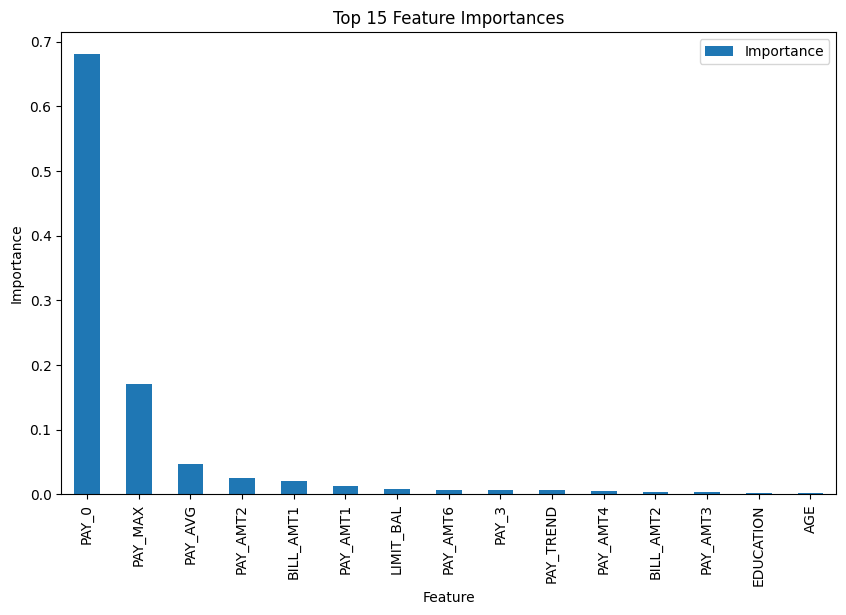

In [89]:
feature_importance.head(15).plot(
     x='Feature',
    y='Importance',
    kind='bar',
    figsize=(10, 6)
)

plt.title("Top 15 Feature Importances")
plt.ylabel("Importance")
plt.xlabel("Feature")
plt.show()

In [90]:
# okay so according to it pay_0 amd pay_max are the one which are show case te most results so now we meed to do feature engineering 

In [94]:
# trying to find the number of delayed month

pay_cols = [
    'PAY_0',
    'PAY_2',
    'PAY_3',
    'PAY_4',
    'PAY_5',
    'PAY_6'
]

credit['DELAY_COUNT'] = (credit[pay_cols] > 0).sum(axis=1)

credit['DELAY_COUNT'].value_counts().sort_index()

credit

credit[pay_cols]

,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6
0,2,2,-1,-1,-2,-2
1,-1,2,0,0,0,2
2,0,0,0,0,0,0
3,0,0,0,0,0,0
4,-1,0,-1,0,0,0
...,...,...,...,...,...,...
29995,0,0,0,0,0,0
29996,-1,-1,-1,-1,0,0
29997,4,3,2,-1,0,0
29998,1,-1,0,0,0,-1


In [100]:
credit['DELAY_COUNT']

0        2
1        2
2        0
3        0
4        0
        ..
29995    0
29996    0
29997    3
29998    1
29999    0
Name: DELAY_COUNT, Length: 30000, dtype: int64

In [101]:
credit.groupby('DELAY_COUNT')['default payment next month'].mean()

DELAY_COUNT
0    0.117104
1    0.298238
2    0.387572
3    0.508666
4    0.573081
5    0.573826
6    0.703207
Name: default payment next month, dtype: float64

In [102]:
credit.groupby('PAY_MAX')['default payment next month'].mean()

PAY_MAX
-2    0.134661
-1    0.147116
 0    0.108306
 1    0.249852
 2    0.435509
 3    0.622307
 4    0.642202
 5    0.507246
 6    0.560000
 7    0.835821
 8    0.560000
Name: default payment next month, dtype: float64

In [103]:
credit.groupby('PAY_AVG')['default payment next month'].mean()

PAY_AVG
-2.000000    0.134661
-1.833333    0.193182
-1.666667    0.174061
-1.500000    0.302191
-1.333333    0.159509
-1.166667    0.148562
-1.000000    0.143029
-0.833333    0.153629
-0.666667    0.157352
-0.500000    0.168709
-0.333333    0.154059
-0.166667    0.145740
 0.000000    0.110871
 0.166667    0.325503
 0.333333    0.337228
 0.500000    0.347626
 0.666667    0.472803
 0.833333    0.421053
 1.000000    0.580000
 1.166667    0.504373
 1.333333    0.646817
 1.500000    0.500000
 1.666667    0.621118
 1.833333    0.544892
 2.000000    0.753744
 2.166667    0.772414
 2.333333    0.632911
 2.500000    0.800000
 2.666667    0.770833
 2.833333    0.800000
 3.000000    0.681818
 3.166667    0.727273
 3.333333    0.500000
 3.500000    0.400000
 3.666667    0.333333
 3.833333    0.000000
 4.000000    0.666667
 4.166667    0.666667
 4.333333    1.000000
 4.500000    0.833333
 4.666667    0.888889
 4.833333    1.000000
 5.000000    0.000000
 5.166667    0.666667
 5.333333    0.800000
 5